
# Introduction to Deep Learning - Assignment 0
# **TASKS**
 - 1: Distance-based classifiers (Class centers, PCA/t-SNE/UMAP, Nearest Mean, KNN)
 - 2: Multi-class Perceptron
 - 3: XOR network with backprop + gradient descent

All experiments are on raw inputs for a fair Task-1 vs Task-2 comparison.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path('.')

train_in_path  = DATA_DIR / 'train_in.csv'
train_out_path = DATA_DIR / 'train_out.csv'
test_in_path   = DATA_DIR / 'test_in.csv'
test_out_path  = DATA_DIR / 'test_out.csv'

# Check files exist
required = [train_in_path, train_out_path, test_in_path, test_out_path]
missing = [p.name for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(f"Missing files: {', '.join(missing)}")

# Load data
X_train = pd.read_csv(train_in_path, header=None).values.astype(float)
y_train = pd.read_csv(train_out_path, header=None).values.reshape(-1).astype(int)
X_test  = pd.read_csv(test_in_path, header=None).values.astype(float)
y_test  = pd.read_csv(test_out_path, header=None).values.reshape(-1).astype(int)

print("Train X:", X_train.shape, "Train y:", y_train.shape)
print("Test  X:", X_test.shape,  "Test  y:", y_test.shape)


Train X: (1707, 256) Train y: (1707,)
Test  X: (1000, 256) Test  y: (1000,)


## Task 1 - Step 1: Class centers and inter-class distances

Centers shape: (10, 256)
Per-class counts: [319 252 202 131 122  88 151 166 144 132]


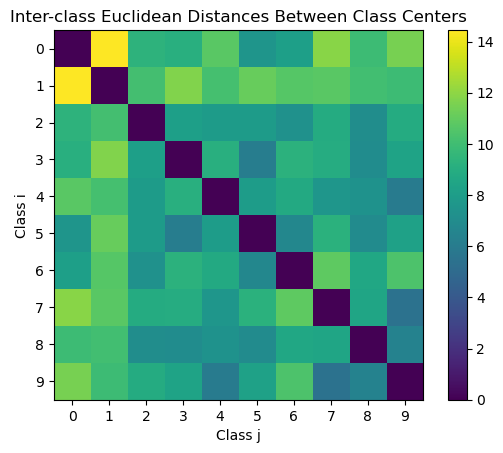

Closest digit-center pairs:
  (7, 9) -> 5.4265
  (4, 9) -> 6.0104
  (3, 5) -> 6.1188
  (8, 9) -> 6.4012
  (5, 6) -> 6.6987
  (5, 8) -> 6.9674
  (3, 8) -> 7.0204
  (2, 8) -> 7.0775
  (2, 6) -> 7.3318
  (4, 8) -> 7.3809


In [2]:
def compute_class_centers(X, y, num_classes=10):
    centers = np.zeros((num_classes, X.shape[1]), dtype=float)
    counts = np.zeros(num_classes, dtype=int)
    for d in range(num_classes):
        mask = (y == d)
        counts[d] = mask.sum()
        centers[d] = X[mask].mean(axis=0)
    return centers, counts

centers, counts = compute_class_centers(X_train, y_train)
print("Centers shape:", centers.shape)
print("Per-class counts:", counts)

# Distance matrix between centers
diff = centers[:, None, :] - centers[None, :, :]
D = np.sqrt((diff**2).sum(axis=2))
fig = plt.figure()
plt.imshow(D, interpolation='nearest')
plt.title("Inter-class Euclidean Distances Between Class Centers")
plt.xlabel("Class j")
plt.ylabel("Class i")
plt.colorbar()
plt.xticks(range(10))
plt.yticks(range(10))
plt.show()

# List closest pairs
pairs = []
for i in range(10):
    for j in range(i+1, 10):
        pairs.append((D[i, j], i, j))
pairs.sort(key=lambda x: x[0])
print("Closest digit-center pairs:")
for dist, i, j in pairs[:10]:
    print(f"  ({i}, {j}) -> {dist:.4f}")


## Task 1 - Step 2: Dimensionality reduction (PCA, t-SNE, UMAP)

PCA explained variance (2D): 0.2854251683633331


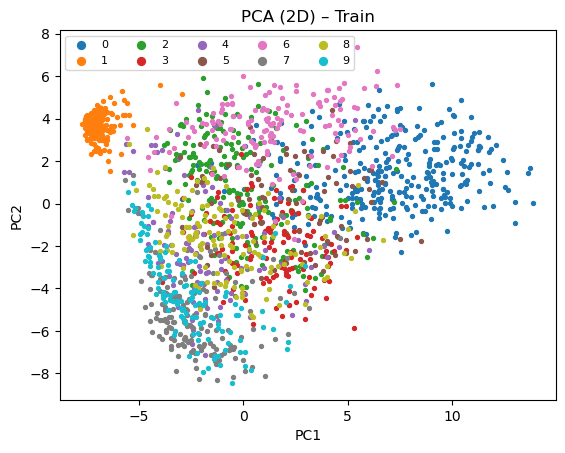

In [3]:
import umap
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

# PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train)
print("PCA explained variance (2D):", pca.explained_variance_ratio_.sum())

fig = plt.figure()
for d in range(10):
    m = (y_train == d)
    plt.scatter(X_pca[m, 0], X_pca[m, 1], s=8, label=str(d))
plt.title("PCA (2D) – Train")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(markerscale=2, fontsize=8, ncols=5)
plt.show()

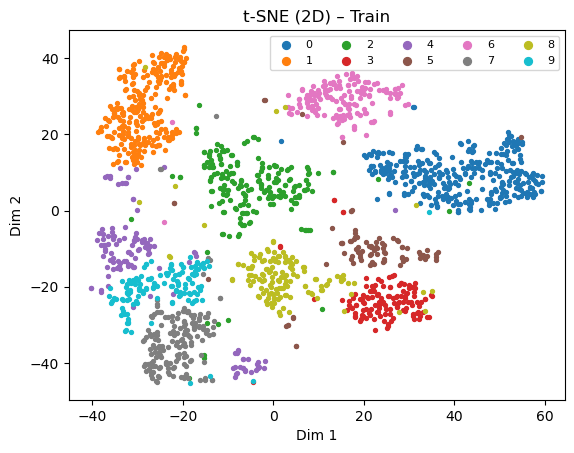

In [4]:
from sklearn.manifold import TSNE

# t-SNE 2D
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42)
X_tsne = tsne.fit_transform(X_train)

fig = plt.figure()
for d in range(10):
    m = (y_train == d)
    plt.scatter(X_tsne[m, 0], X_tsne[m, 1], s=8, label=str(d))
plt.title("t-SNE (2D) – Train")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend(markerscale=2, fontsize=8, ncols=5)
plt.show()

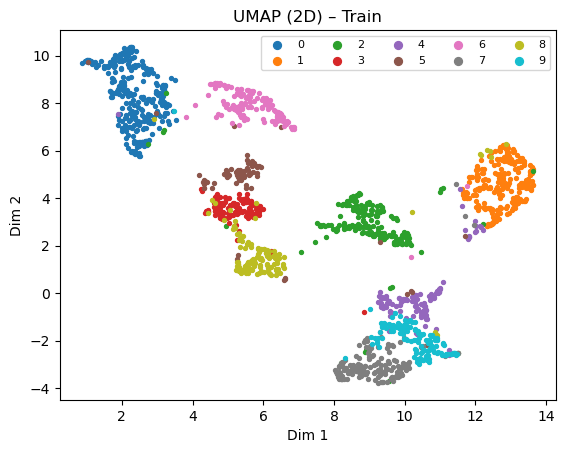

In [5]:
try:
    import umap
    UMAP_AVAILABLE = True
except Exception:
    UMAP_AVAILABLE = False
    print("UMAP not available; skipping UMAP plot.")

if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        metric="euclidean", random_state=42)
    X_umap = reducer.fit_transform(X_train)
    fig = plt.figure()
    for d in range(10):
        m = (y_train == d)
        plt.scatter(X_umap[m, 0], X_umap[m, 1], s=8, label=str(d))
    plt.title("UMAP (2D) – Train")
    plt.xlabel("Dim 1"); plt.ylabel("Dim 2")
    plt.legend(markerscale=2, fontsize=8, ncols=5)
    plt.show()

## Task 1 - Step 3: Nearest Mean Classifier (NMC)

NMC accuracy – train: 0.8635, test: 0.8040


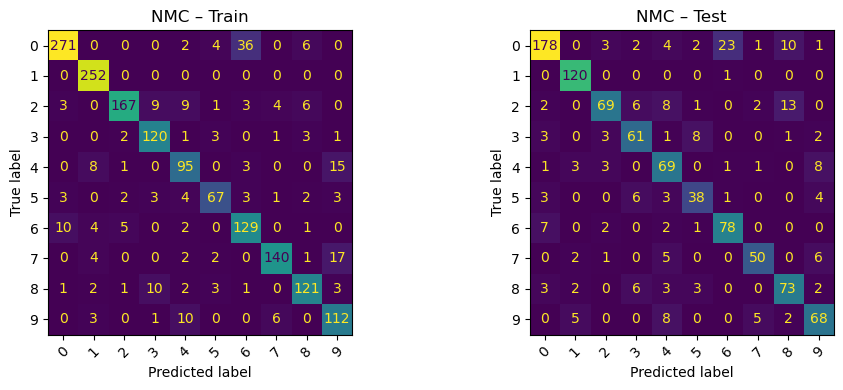

In [6]:
def predict_nmc(X, centers):
    x2 = (X**2).sum(axis=1, keepdims=True)
    c2 = (centers**2).sum(axis=1, keepdims=True).T
    d2 = x2 + c2 - 2 * X @ centers.T
    return d2.argmin(axis=1)

y_pred_tr_nmc = predict_nmc(X_train, centers)
y_pred_te_nmc = predict_nmc(X_test, centers)

acc_tr = accuracy_score(y_train, y_pred_tr_nmc)
acc_te = accuracy_score(y_test,  y_pred_te_nmc)
print(f"NMC accuracy – train: {acc_tr:.4f}, test: {acc_te:.4f}")

fig, axes = plt.subplots(1,2, figsize=(10,4))
cm_tr = confusion_matrix(y_train, y_pred_tr_nmc, labels=list(range(10)))
ConfusionMatrixDisplay(cm_tr, display_labels=list(range(10))).plot(ax=axes[0], colorbar=False, xticks_rotation=45)
axes[0].set_title("NMC – Train")
cm_te = confusion_matrix(y_test, y_pred_te_nmc, labels=list(range(10)))
ConfusionMatrixDisplay(cm_te, display_labels=list(range(10))).plot(ax=axes[1], colorbar=False, xticks_rotation=45)
axes[1].set_title("NMC – Test")
plt.tight_layout(); plt.show()

## Task 1 - Step 4: KNN Classifier

KNN accuracy sweep (train / test):
k=1: 1.0000 / 0.9150
k=3: 1.0000 / 0.9160
k=5: 1.0000 / 0.9160
k=7: 1.0000 / 0.9100
Using k=3 for confusion matrices (best test accuracy).


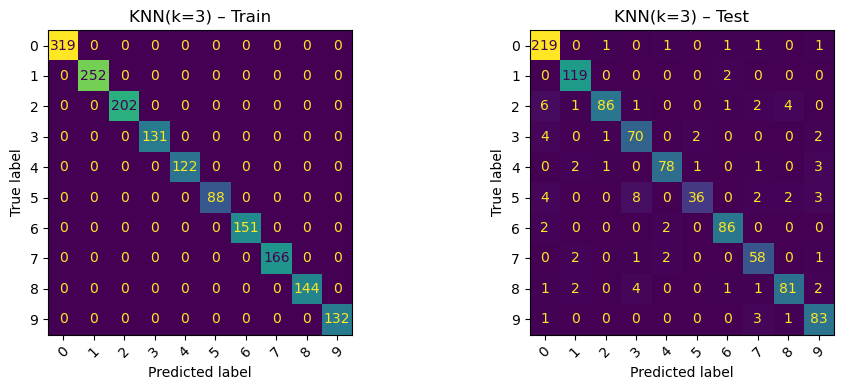

In [7]:
print("KNN accuracy sweep (train / test):")
best_k, best_te = None, -1
for k in (1,3,5,7):
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean')
    knn.fit(X_train, y_train)
    acc_tr = (knn.predict(X_train) == y_train).mean()
    acc_te = (knn.predict(X_test)  == y_test ).mean()
    print(f"k={k}: {acc_tr:.4f} / {acc_te:.4f}")
    if acc_te > best_te:
        best_te, best_k = acc_te, k

print(f"Using k={best_k} for confusion matrices (best test accuracy).")
knn = KNeighborsClassifier(n_neighbors=best_k, weights='distance', metric='euclidean')
knn.fit(X_train, y_train)
y_pred_tr = knn.predict(X_train)
y_pred_te = knn.predict(X_test)

fig, axes = plt.subplots(1,2, figsize=(10,4))
cm_tr = confusion_matrix(y_train, y_pred_tr, labels=list(range(10)))
ConfusionMatrixDisplay(cm_tr, display_labels=list(range(10))).plot(ax=axes[0], colorbar=False, xticks_rotation=45)
axes[0].set_title(f"KNN(k={best_k}) – Train")
cm_te = confusion_matrix(y_test, y_pred_te, labels=list(range(10)))
ConfusionMatrixDisplay(cm_te, display_labels=list(range(10))).plot(ax=axes[1], colorbar=False, xticks_rotation=45)
axes[1].set_title(f"KNN(k={best_k}) – Test")
plt.tight_layout(); plt.show()

In [8]:
# Save Task-1 final test accuracy for comparisonwith Task 2
acc_test_knn = (y_pred_te == y_test).mean()
print(f"KNN(k={best_k}) – final test accuracy: {acc_test_knn:.4f}")

KNN(k=3) – final test accuracy: 0.9160


## Task 2 - Implement a multi-class perceptron algorithm

In [9]:
# Task 2: Multi-class perceptron and squared-loss GD

rng = np.random.default_rng(42)

def add_bias(X):
    return np.hstack([X, np.ones((X.shape[0], 1), dtype=X.dtype)])

Xtr_b = add_bias(X_train)
Xte_b = add_bias(X_test)

num_features = Xtr_b.shape[1]   # 257 if D=256
num_classes  = 10
W = rng.normal(0.0, 0.01, size=(num_features, num_classes))

def one_hot(y, C):
    Y = np.zeros((y.shape[0], C), dtype=float)
    Y[np.arange(y.shape[0]), y] = 1.0
    return Y

Ytr_oh = one_hot(y_train, num_classes)
Yte_oh = one_hot(y_test,  num_classes)

def perceptron_epoch(Xb, Y_onehot, W, lr=0.005, l2=1e-5, max_grad_norm=5.0):
    
    N = Xb.shape[0]
    scores = Xb @ W
    data_grad = (2.0 / N) * (Xb.T @ (scores - Y_onehot))
    grad = data_grad + 2.0 * l2 * W

    if max_grad_norm is not None:
        gnorm = np.linalg.norm(grad)
        if gnorm > max_grad_norm:
            grad *= (max_grad_norm / (gnorm + 1e-12))

    W = W - lr * grad

    data_loss = np.sum((scores - Y_onehot)**2) / N
    return W, data_loss

def accuracy(Xb, y, W):
    y_pred = (Xb @ W).argmax(axis=1)
    return (y_pred == y).mean()

# Train loop 

epochs = 25
lr = 0.005     
l2 = 1e-5      
clip = 5.0    

train_acc_hist = []
test_acc_hist  = []
train_loss_hist = []
test_loss_hist  = []


print(f"Perceptron RAW settings → epochs={epochs}, lr={lr}, l2={l2}, clip={clip}")
print(f"Shapes: Xtr_b={Xtr_b.shape}, Xte_b={Xte_b.shape}")

for ep in range(epochs):
    W, train_loss = perceptron_epoch(Xtr_b, Ytr_oh, W, lr=lr, l2=l2, max_grad_norm=clip)

    # Metrics after update
    tr_scores = Xtr_b @ W
    te_scores = Xte_b @ W

    train_acc = accuracy(Xtr_b, y_train, W)
    test_acc  = accuracy(Xte_b, y_test,  W)
    test_loss = np.sum((te_scores - Yte_oh)**2) / Xte_b.shape[0]

    train_acc_hist.append(train_acc)
    test_acc_hist.append(test_acc)
    train_loss_hist.append(train_loss)
    test_loss_hist.append(test_loss)

    print(f"Epoch {ep+1:02d}: "
          f"train_loss={train_loss:.6f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.6f}, test_acc={test_acc:.4f}")

Perceptron RAW settings → epochs=25, lr=0.005, l2=1e-05, clip=5.0
Shapes: Xtr_b=(1707, 257), Xte_b=(1000, 257)
Epoch 01: train_loss=1.041362, train_acc=0.3134, test_loss=0.907197, test_acc=0.3060
Epoch 02: train_loss=0.896611, train_acc=0.3814, test_loss=0.830018, test_acc=0.3740
Epoch 03: train_loss=0.811600, train_acc=0.4277, test_loss=0.777042, test_acc=0.4190
Epoch 04: train_loss=0.754517, train_acc=0.4733, test_loss=0.735302, test_acc=0.4570
Epoch 05: train_loss=0.709012, train_acc=0.5167, test_loss=0.701688, test_acc=0.5010
Epoch 06: train_loss=0.671940, train_acc=0.5630, test_loss=0.674045, test_acc=0.5310
Epoch 07: train_loss=0.641130, train_acc=0.6034, test_loss=0.650875, test_acc=0.5680
Epoch 08: train_loss=0.615064, train_acc=0.6327, test_loss=0.631127, test_acc=0.5910
Epoch 09: train_loss=0.592666, train_acc=0.6544, test_loss=0.614049, test_acc=0.6140
Epoch 10: train_loss=0.573160, train_acc=0.6801, test_loss=0.599095, test_acc=0.6330
Epoch 11: train_loss=0.555978, train_ac

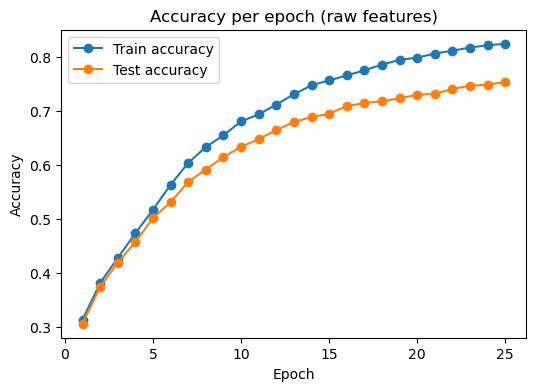

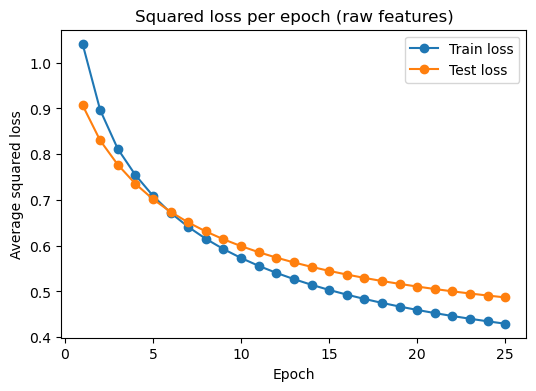

In [10]:
# Accuracy plot
plt.figure(figsize=(6,4))
plt.plot(range(1, epochs+1), train_acc_hist, marker='o', label="Train accuracy")
plt.plot(range(1, epochs+1), test_acc_hist,  marker='o', label="Test accuracy")
plt.title("Accuracy per epoch (raw features)")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(6,4))
plt.plot(range(1, epochs+1), train_loss_hist, marker='o', label="Train loss")
plt.plot(range(1, epochs+1), test_loss_hist,  marker='o', label="Test loss")
plt.title("Squared loss per epoch (raw features)")
plt.xlabel("Epoch"); plt.ylabel("Average squared loss"); plt.legend()
plt.show()

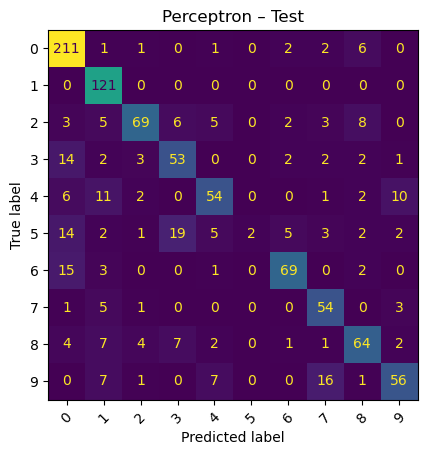

In [11]:
y_pred_perc = (Xte_b @ W).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred_perc, labels=list(range(10)))
ConfusionMatrixDisplay(cm, display_labels=list(range(10))).plot(colorbar=False, xticks_rotation=45)
plt.title("Perceptron – Test"); plt.show()


Final test accuracy across seeds:
  lr=0.001  -> mean=0.4620, std=0.0168, accs=[0.488, 0.45, 0.448, 0.448, 0.476]
  lr=0.002  -> mean=0.6094, std=0.0095, accs=[0.61, 0.601, 0.597, 0.616, 0.623]
  lr=0.005  -> mean=0.7652, std=0.0047, accs=[0.769, 0.757, 0.768, 0.769, 0.763]
  lr=0.01   -> mean=0.8204, std=0.0085, accs=[0.829, 0.815, 0.829, 0.822, 0.807]


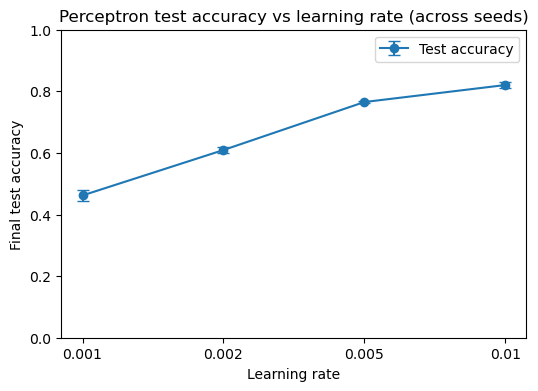

In [12]:
# Repeat
seeds = [0, 1, 2, 3, 4]
lrs   = [0.001, 0.002, 0.005, 0.01]

def run_perceptron_once(seed, lr, epochs=25, l2=1e-5, clip=5.0):
    rng_local = np.random.default_rng(seed)
    W_local = rng_local.normal(0.0, 0.01, size=(Xtr_b.shape[1], num_classes))
    for _ in range(epochs):
        W_local, _ = perceptron_epoch(Xtr_b, Ytr_oh, W_local, lr=lr, l2=l2, max_grad_norm=clip)
    y_pred = (Xte_b @ W_local).argmax(axis=1)
    return (y_pred == y_test).mean()

results = {}
for lr in lrs:
    accs = []
    for sd in seeds:
        accs.append(run_perceptron_once(sd, lr))
    results[lr] = accs

# Print summary
print("Final test accuracy across seeds:")
for lr, accs in results.items():
    print(f"  lr={lr:<6} -> mean={np.mean(accs):.4f}, std={np.std(accs):.4f}, accs={accs}")

# plot: 
means = [np.mean(results[lr]) for lr in lrs]
stds  = [np.std(results[lr]) for lr in lrs]

plt.figure(figsize=(6,4))
xs = np.arange(len(lrs))+1
plt.errorbar(xs, means, yerr=stds, fmt='-o', capsize=4, label="Test accuracy")
plt.xticks(xs, [str(lr) for lr in lrs])
plt.xlabel("Learning rate")
plt.ylabel("Final test accuracy")
plt.title("Perceptron test accuracy vs learning rate (across seeds)")
plt.ylim(0,1)
plt.legend(); plt.show()

In [13]:
# Perceptron accuracies
perc_final_acc = test_acc_hist[-1]   
perc_best_acc  = max(test_acc_hist) 

print("Accuracy comparison (Task-1 vs Task-2)")
print(f"Task 1 (k-NN, k={best_k}) test acc : {acc_test_knn:.4f}")
print(f"Task 2 (Perceptron) final test acc : {perc_final_acc:.4f}")
print(f"Task 2 (Perceptron) best  test acc : {perc_best_acc:.4f}")

Accuracy comparison (Task-1 vs Task-2)
Task 1 (k-NN, k=3) test acc : 0.9160
Task 2 (Perceptron) final test acc : 0.7530
Task 2 (Perceptron) best  test acc : 0.7530


In [14]:

results_table = pd.DataFrame([
    {"Task":"1","Model":f"NMC","Params":"—",
     "TrainAcc":(y_pred_tr_nmc==y_train).mean(), "TestAcc":(y_pred_te_nmc==y_test).mean()},
    {"Task":"1","Model":f"KNN(k={best_k})","Params":"weights=distance, metric=euclidean",
     "TrainAcc":(y_pred_tr==y_train).mean(), "TestAcc":(y_pred_te==y_test).mean()},
    {"Task":"2","Model":"Perceptron","Params":f"lr={lr}, epochs={epochs}, loss=squared",
     "TrainAcc":train_acc_hist[-1], "TestAcc":test_acc_hist[-1]},
])
display(results_table)



,Task,Model,Params,TrainAcc,TestAcc
0,1,NMC,—,0.863503,0.804
1,1,KNN(k=3),"weights=distance, metric=euclidean",1.000000,0.916
2,2,Perceptron,"lr=0.01, epochs=25, loss=squared",0.823667,0.753


## Task 3 -  Implement the XOR network and the Gradient Descent Algorithm

In [15]:
# Task 3: XOR network from scratch

X = np.array([
    [0., 0.],
    [0., 1.],
    [1., 0.],
    [1., 1.]
], dtype=float)

y = np.array([0., 1., 1., 0.], dtype=float)  # targets

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_prime(z):
    s = sigmoid(z)
    return s * (1.0 - s)

def mse(yhat, ytrue):
    return np.mean((yhat - ytrue) ** 2)

def predict_binary(yhat, thresh=0.5):
    return (yhat >= thresh).astype(float)

class XORNet:
    def __init__(self, rng, weight_scale=0.5):
        self.U = rng.uniform(-weight_scale, weight_scale, size=(2, 2))
        self.c = rng.uniform(-weight_scale, weight_scale, size=(2,))
        self.w = rng.uniform(-weight_scale, weight_scale, size=(2,))
        self.b = rng.uniform(-weight_scale, weight_scale)

    def forward(self, X):
        z_h = X @ self.U + self.c           # (N,2)
        h   = sigmoid(z_h)                  # (N,2)
        z_y = h @ self.w + self.b           # (N,)
        yhat = sigmoid(z_y)                 # (N,)
        cache = {"X": X, "z_h": z_h, "h": h, "z_y": z_y, "yhat": yhat}
        return yhat, cache

    def gradients(self, y, cache):
        
        X, z_h, h, z_y, yhat = cache["X"], cache["z_h"], cache["h"], cache["z_y"], cache["yhat"]
        N = X.shape[0]

        dL_dyhat = 2.0 * (yhat - y) / N
        dL_dz_y = dL_dyhat * sigmoid_prime(z_y)         

        # Gradients for output layer
        grad_w = h.T @ dL_dz_y                          
        grad_b = np.sum(dL_dz_y)                         

        dL_dh = np.outer(dL_dz_y, self.w)               

        dL_dz_h = dL_dh * sigmoid_prime(z_h)             

        grad_U = X.T @ dL_dz_h                           
        grad_c = np.sum(dL_dz_h, axis=0)                

        return {"U": grad_U, "c": grad_c, "w": grad_w, "b": grad_b}

    def step(self, grads, lr):
        self.U -= lr * grads["U"]
        self.c -= lr * grads["c"]
        self.w -= lr * grads["w"]
        self.b -= lr * grads["b"]

    def params_vector(self):
    
        return np.concatenate([self.U.ravel(), self.c.ravel(), self.w.ravel(), np.array([self.b])])

In [16]:

# Training loop (batch GD)

def train_once(seed=42, lr=0.5, max_epochs=5000, tol=1e-5, verbose=True, plot=True):
    rng = np.random.default_rng(seed)
    net = XORNet(rng, weight_scale=0.5)

    losses = []
    miscls = []

    for epoch in range(1, max_epochs + 1):
        yhat, cache = net.forward(X)
        L = mse(yhat, y)
        ybin = predict_binary(yhat, 0.5)
        mis = int(np.sum(ybin != y))

        losses.append(L)
        miscls.append(mis)

        grads = net.gradients(y, cache)
        net.step(grads, lr)

        if mis == 0 and L < tol:
            if verbose:
                print(f"[seed={seed} | lr={lr}] Early stop @ epoch {epoch}: MSE={L:.6f}, miscls={mis}")
            break
        
        if mis == 0:
            if verbose:
                print(f"[seed={seed} | lr={lr}] Perfect classification @ epoch {epoch}: MSE={L:.6f}")
            break
        if verbose and (epoch % 1000 == 0):
            print(f"Epoch {epoch:5d}  MSE={L:.6f}  miscls={mis}")

    yhat, _ = net.forward(X)
    ybin = predict_binary(yhat, 0.5)
    final_mse = mse(yhat, y)
    final_mis = int(np.sum(ybin != y))

    print("\n Final results")
    print(f"seed={seed} | lr={lr} | epochs_run={len(losses)}")
    print(f"MSE={final_mse:.8f} | misclassified={final_mis} / 4")
    print("Predictions (probabilities -> binary):")
    for xi, yi, pi, bi in zip(X, y, yhat, ybin):
        print(f"  X={xi.astype(int)}  y={int(yi)}  p̂={pi:.6f}  ŷ={int(bi)}")

    if plot:
        fig, ax = plt.subplots(1, 1, figsize=(6, 4))
        ax.plot(losses, lw=2)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("MSE")
        ax.set_title(f"XOR – Training loss (seed={seed}, lr={lr})")
        ax.grid(True)
        plt.show()

    return net, np.array(losses), np.array(miscls)



 Final results
seed=0 | lr=0.5 | epochs_run=6483
MSE=0.13797213 | misclassified=0 / 4
Predictions (probabilities -> binary):
  X=[0 0]  y=0  p̂=0.455994  ŷ=0
  X=[0 1]  y=1  p̂=0.785820  ŷ=1
  X=[1 0]  y=1  p̂=0.500800  ŷ=1
  X=[1 1]  y=0  p̂=0.221097  ŷ=0


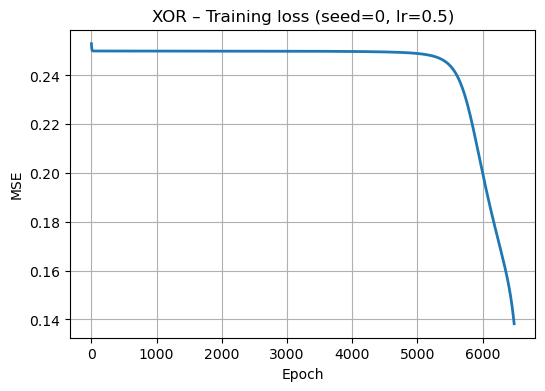

Found perfect classifier with seed=0 lr=0.5.


 Final results
seed=1 | lr=0.5 | epochs_run=4185
MSE=0.12167590 | misclassified=0 / 4
Predictions (probabilities -> binary):
  X=[0 0]  y=0  p̂=0.190709  ŷ=0
  X=[0 1]  y=1  p̂=0.639997  ŷ=1
  X=[1 0]  y=1  p̂=0.732102  ŷ=1
  X=[1 1]  y=0  p̂=0.498961  ŷ=0


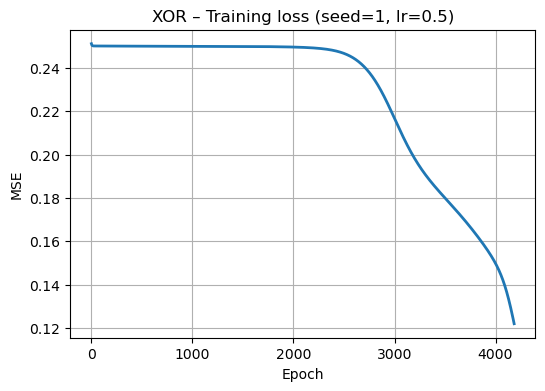

Found perfect classifier with seed=1 lr=0.5.


 Final results
seed=2 | lr=0.5 | epochs_run=3032
MSE=0.12467907 | misclassified=0 / 4
Predictions (probabilities -> binary):
  X=[0 0]  y=0  p̂=0.145633  ŷ=0
  X=[0 1]  y=1  p̂=0.637444  ŷ=1
  X=[1 0]  y=1  p̂=0.687945  ŷ=1
  X=[1 1]  y=0  p̂=0.498681  ŷ=0


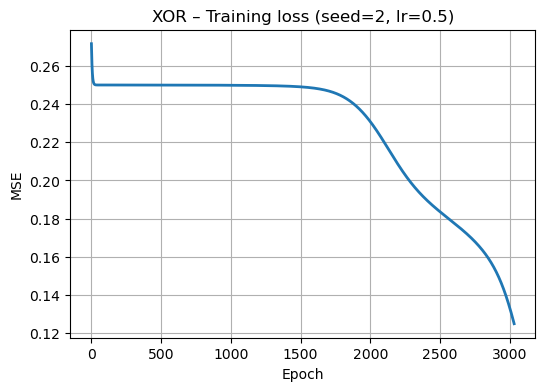

Found perfect classifier with seed=2 lr=0.5.


 Final results
seed=3 | lr=0.3 | epochs_run=4952
MSE=0.13069404 | misclassified=0 / 4
Predictions (probabilities -> binary):
  X=[0 0]  y=0  p̂=0.351131  ŷ=0
  X=[0 1]  y=1  p̂=0.771158  ŷ=1
  X=[1 0]  y=1  p̂=0.501091  ŷ=1
  X=[1 1]  y=0  p̂=0.313375  ŷ=0


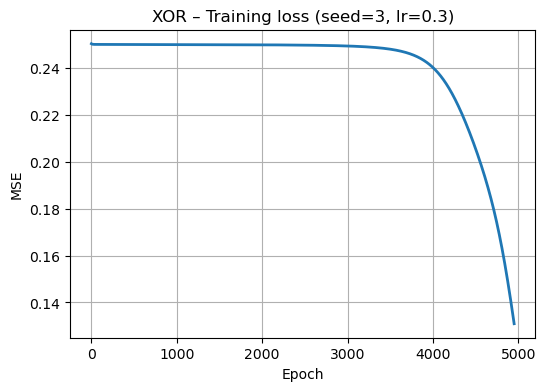

Found perfect classifier with seed=3 lr=0.3.


 Final results
seed=4 | lr=0.7 | epochs_run=1466
MSE=0.13259372 | misclassified=0 / 4
Predictions (probabilities -> binary):
  X=[0 0]  y=0  p̂=0.214197  ŷ=0
  X=[0 1]  y=1  p̂=0.661243  ŷ=1
  X=[1 0]  y=1  p̂=0.652336  ŷ=1
  X=[1 1]  y=0  p̂=0.498867  ŷ=0


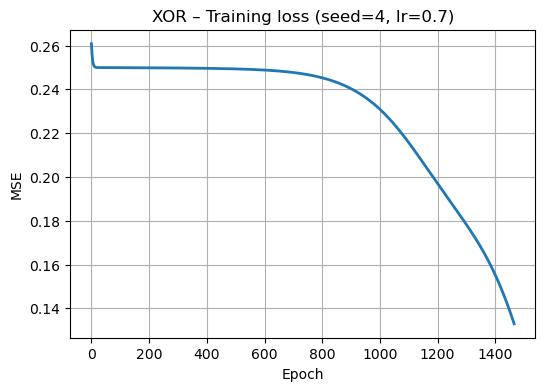

Found perfect classifier with seed=4 lr=0.7.


In [17]:

trials = [
    {"seed": 0,  "lr": 0.5},
    {"seed": 1,  "lr": 0.5},
    {"seed": 2,  "lr": 0.5},
    {"seed": 3,  "lr": 0.3},
    {"seed": 4,  "lr": 0.7},
]

solutions = []
for cfg in trials:
    print("\n" + "="*70)
    net, losses, mis = train_once(seed=cfg["seed"], lr=cfg["lr"], max_epochs=10000, tol=1e-6, verbose=False, plot=True)

    yhat, _ = net.forward(X)
    if np.all(predict_binary(yhat) == y):
        print(f"Found perfect classifier with seed={cfg['seed']} lr={cfg['lr']}.")
    else:
        print(f"Did not reach perfect classification with seed={cfg['seed']} lr={cfg['lr']}.")
    solutions.append((cfg, net, losses, mis))

def print_weights_named(net):
    w11, w21 = net.U[0,0], net.U[1,0]   # x1,x2 -> h1
    w12, w22 = net.U[0,1], net.U[1,1]   # x1,x2 -> h2
    c1, c2   = net.c[0], net.c[1]
    w1, w2   = net.w[0], net.w[1]
    b        = net.b

    print("Weights and biases:")
    print(f"  w11 = {w11:.6f}")
    print(f"  w21 = {w21:.6f}")
    print(f"  w12 = {w12:.6f}")
    print(f"  w22 = {w22:.6f}")
    print(f"  c1  = {c1:.6f}")
    print(f"  c2  = {c2:.6f}")
    print(f"  w1  = {w1:.6f}")
    print(f"  w2  = {w2:.6f}")
    print(f"  b   = {b:.6f}")

In [18]:
# Inspect one successful solution's parameters
for cfg, net, losses, mis in solutions:
    yhat, _ = net.forward(X)
    if np.all(predict_binary(yhat) == y):
        print("\nOne successful parameter set:")
        print(f"seed={cfg['seed']} lr={cfg['lr']}")
        print("U (input->hidden):")
        print(net.U)
        print("c (hidden biases):", net.c)
        print("w (hidden->output):", net.w)
        print("b (output bias):", net.b)
        break



One successful parameter set:
seed=0 lr=0.5
U (input->hidden):
[[ 4.20619543  0.74603337]
 [-4.49971282 -2.37785319]]
c (hidden biases): [3.07062429 1.01656282]
w (hidden->output): [-4.003899    2.97259107]
b (output bias): 1.467124793834105


In [19]:

net, losses, mis = train_once(seed=0, lr=0.5, verbose=True, plot=False)
print_weights_named(net)


Epoch  1000  MSE=0.249987  miscls=2
Epoch  2000  MSE=0.249969  miscls=2
Epoch  3000  MSE=0.249930  miscls=2
Epoch  4000  MSE=0.249812  miscls=2
Epoch  5000  MSE=0.248985  miscls=2

 Final results
seed=0 | lr=0.5 | epochs_run=5000
MSE=0.24898197 | misclassified=2 / 4
Predictions (probabilities -> binary):
  X=[0 0]  y=0  p̂=0.513360  ŷ=1
  X=[0 1]  y=1  p̂=0.514941  ŷ=1
  X=[1 0]  y=1  p̂=0.486531  ŷ=0
  X=[1 1]  y=0  p̂=0.483173  ŷ=0
Weights and biases:
  w11 = 0.612327
  w21 = -0.616665
  w12 = -0.407680
  w22 = -0.554884
  c1  = 0.658875
  c2  = 1.012933
  w1  = -0.489985
  w2  = 0.548698
  b   = -0.026163
